In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [32]:
from datetime import datetime

In [2]:
pwd

'/Users/danielzhang/Documents/Python-Projects/DataAnalysis'

In [3]:
cd ScoringCard/

/Users/danielzhang/Documents/Python-Projects/DataAnalysis/ScoringCard


# 数据集

In [13]:
ls

03-scorecard_model_development.py*
PPD_LogInfo_3_1_Training_Set.csv*
PPD_Training_Master_GBK_3_1_Training_Set.csv*
PPD_Userupdate_Info_3_1_Training_Set.csv*
评分卡模型-V1.ipynb


+ 数据源介绍

| 数据源                                    | 字段                                     | 含义               |
| ----------------------------------------- | ---------------------------------------- | ------------------ |
| PPD_Training_Master_GBK_3_1_ Training_Set | Idx                                      | 用户的唯一标识     |
|            | Target                                    | 目标变量，以1、0表示违约与非违约         |                    |
|            | UserInfo_*                                | 用户属性，多以归属地内容，有缺失         |                    |
|            | ThirdParty_Info_Period*                   | 除-1外，其他都是非负整数。-1可能是特殊值 |                    |
|            | ListingInfo                               | 贷款发放日期                             |                    |
| PPD_LogInfo_3_1_Training_Set              | LogInfo3                                 | 登录日期           |
|            | LogInfo*                                  | 登录事件代码                             |                    |
| PPD_Userupdate_Info_3_1_Train ing_Set     | UserupdateInfo1                          | 更改信息的所属字段 |
|            | UserupdateInfo2                           | 更改日期                                 |                |

+ 信贷客户在拍拍贷上的申报 信息和部分三方数据信息，以及需要预测的目标变量

In [23]:
# 注意编码必须要是GBK，UTF打不开
basic_info = pd.read_csv("PPD_Training_Master_GBK_3_1_Training_Set.csv",header=0, encoding='gbk')

+ 信贷客户的登彔信息

In [24]:
login_info = pd.read_csv("PPD_LogInfo_3_1_Training_Set.csv")

+ 部分客户的信息修改行为

In [25]:
update_info = pd.read_csv("PPD_Userupdate_Info_3_1_Training_Set.csv")

In [26]:
print("basic_info.shape:  ",basic_info.shape)
print("login_info.shape:  ",login_info.shape)
print("update_info.shape:  ",update_info.shape)

basic_info.shape:   (30000, 228)
login_info.shape:   (580551, 5)
update_info.shape:   (372463, 4)


In [27]:
basic_info.head()

,Idx,UserInfo_1,UserInfo_2,UserInfo_3,UserInfo_4,WeblogInfo_1,WeblogInfo_2,WeblogInfo_3,WeblogInfo_4,WeblogInfo_5,...,SocialNetwork_10,SocialNetwork_11,SocialNetwork_12,SocialNetwork_13,SocialNetwork_14,SocialNetwork_15,SocialNetwork_16,SocialNetwork_17,target,ListingInfo
0,10001,1.0,深圳,4.0,深圳,NaN,1.0,NaN,1.0,1.0,...,222,-1,0,0,0,0,0,1,0,2014/3/5
1,10002,1.0,温州,4.0,温州,NaN,0.0,NaN,1.0,1.0,...,1,-1,0,0,0,0,0,2,0,2014/2/26
2,10003,1.0,宜昌,3.0,宜昌,NaN,0.0,NaN,2.0,2.0,...,-1,-1,-1,1,0,0,0,0,0,2014/2/28
3,10006,4.0,南平,1.0,南平,NaN,NaN,NaN,NaN,NaN,...,-1,-1,-1,0,0,0,0,0,0,2014/2/25
4,10007,5.0,辽阳,1.0,辽阳,NaN,0.0,NaN,1.0,1.0,...,-1,-1,-1,0,0,0,0,0,0,2014/2/27


In [30]:
list(basic_info.columns)

['Idx',
 'UserInfo_1',
 'UserInfo_2',
 'UserInfo_3',
 'UserInfo_4',
 'WeblogInfo_1',
 'WeblogInfo_2',
 'WeblogInfo_3',
 'WeblogInfo_4',
 'WeblogInfo_5',
 'WeblogInfo_6',
 'WeblogInfo_7',
 'WeblogInfo_8',
 'WeblogInfo_9',
 'WeblogInfo_10',
 'WeblogInfo_11',
 'WeblogInfo_12',
 'WeblogInfo_13',
 'WeblogInfo_14',
 'WeblogInfo_15',
 'WeblogInfo_16',
 'WeblogInfo_17',
 'WeblogInfo_18',
 'UserInfo_5',
 'UserInfo_6',
 'UserInfo_7',
 'UserInfo_8',
 'UserInfo_9',
 'UserInfo_10',
 'UserInfo_11',
 'UserInfo_12',
 'UserInfo_13',
 'UserInfo_14',
 'UserInfo_15',
 'UserInfo_16',
 'UserInfo_17',
 'UserInfo_18',
 'UserInfo_19',
 'UserInfo_20',
 'UserInfo_21',
 'UserInfo_22',
 'UserInfo_23',
 'UserInfo_24',
 'Education_Info1',
 'Education_Info2',
 'Education_Info3',
 'Education_Info4',
 'Education_Info5',
 'Education_Info6',
 'Education_Info7',
 'Education_Info8',
 'WeblogInfo_19',
 'WeblogInfo_20',
 'WeblogInfo_21',
 'WeblogInfo_23',
 'WeblogInfo_24',
 'WeblogInfo_25',
 'WeblogInfo_26',
 'WeblogInfo_27'

In [28]:
login_info.head()

,Idx,Listinginfo1,LogInfo1,LogInfo2,LogInfo3
0,10001,2014-03-05,107,6,2014-02-20
1,10001,2014-03-05,107,6,2014-02-23
2,10001,2014-03-05,107,6,2014-02-24
3,10001,2014-03-05,107,6,2014-02-25
4,10001,2014-03-05,107,6,2014-02-27


In [29]:
update_info.head()

,Idx,ListingInfo1,UserupdateInfo1,UserupdateInfo2
0,10001,2014/03/05,_EducationId,2014/02/20
1,10001,2014/03/05,_HasBuyCar,2014/02/20
2,10001,2014/03/05,_LastUpdateDate,2014/02/20
3,10001,2014/03/05,_MarriageStatusId,2014/02/20
4,10001,2014/03/05,_MobilePhone,2014/02/20


---------------

# 特征工程

## 特征构造

+ 提取申请日期，计算申请日期和贷款发放日期的差，查看日期差的分布  
这个信息在login_info表里

In [40]:
login_info['login_date'] = login_info['LogInfo3'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))
login_info['listing_date'] = login_info['Listinginfo1'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))

In [49]:
# 计算登录日期和贷款发放日期差值
login_info['date_diff'] = login_info['listing_date'] - login_info['login_date']
# 对超过一年的差值，强制转换为365天
login_info['date_diff'] = login_info['date_diff'].apply(lambda x: min(x.days, 365))

In [50]:
login_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580551 entries, 0 to 580550
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Idx           580551 non-null  int64         
 1   Listinginfo1  580551 non-null  object        
 2   LogInfo1      580551 non-null  int64         
 3   LogInfo2      580551 non-null  int64         
 4   LogInfo3      580551 non-null  object        
 5   login_date    580551 non-null  datetime64[ns]
 6   listing_date  580551 non-null  datetime64[ns]
 7   date_diff     580551 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(2)
memory usage: 35.4+ MB


In [51]:
login_info.head()

,Idx,Listinginfo1,LogInfo1,LogInfo2,LogInfo3,login_date,listing_date,date_diff
0,10001,2014-03-05,107,6,2014-02-20,2014-02-20,2014-03-05,13
1,10001,2014-03-05,107,6,2014-02-23,2014-02-23,2014-03-05,10
2,10001,2014-03-05,107,6,2014-02-24,2014-02-24,2014-03-05,9
3,10001,2014-03-05,107,6,2014-02-25,2014-02-25,2014-03-05,8
4,10001,2014-03-05,107,6,2014-02-27,2014-02-27,2014-03-05,6


Text(0.5, 1.0, 'date_diff histogram')

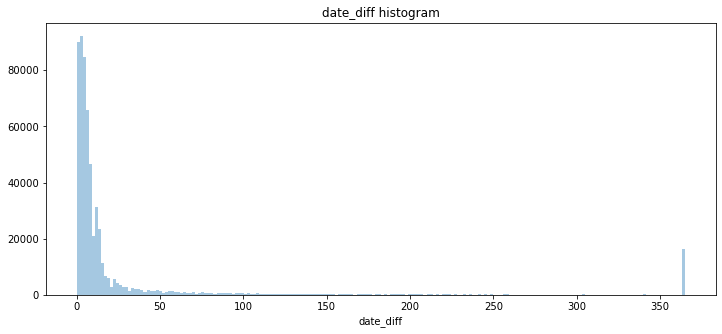

In [60]:
# 查看日期差的分布
fig, ax = plt.subplots(figsize=(12,5))
g = sns.distplot(login_info['date_diff'], bins=200, kde=False,ax=ax)
g.set_title("date_diff histogram")

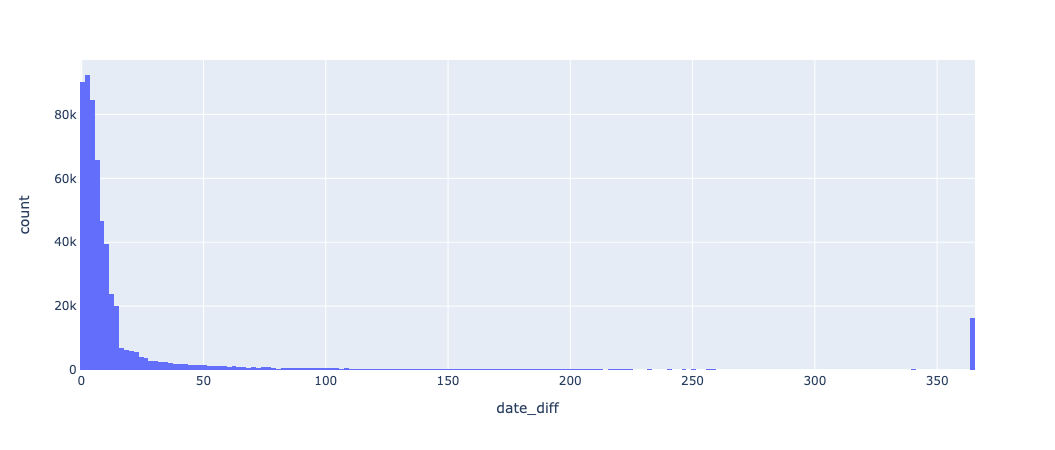

In [53]:
px.histogram(data_frame=login_info, x='date_diff', nbins=200)

+ 计算不同时间窗口行为次数的分布——这个好像没啥用

In [61]:
def TimeWindowSelection(df, daysCol, time_windows):
    '''
    :param df: the dataset containg variabel of days
    :param daysCol: the column of days
    :param time_windows: the list of time window
    :return:
    '''
    freq_tw = {}
    for tw in time_windows:
        freq = sum(df[daysCol].apply(lambda x: int(x<=tw)))
        freq_tw[tw] = freq
    return freq_tw

In [62]:
timeWindows = TimeWindowSelection(login_info, 'date_diff', range(30,361,30))
timeWindows

+ 计算每个用户在不同时间窗口内的行为次数  
login_info表里 LogInfo1 和 LogInfo2 这两个字段代表了不同**种类**的登录行为。
需要统计的有三个值：
  + 每个用户（Idx区分）在不同时间窗口内的上述两类行为的登录次数
  + 每个用户在不同时间窗口内，不同登录行为的次数
  + 每个用户在不同时间窗口内，不同登录行为的平均数  

  这样，**每个时间窗口**会产生 $2 \times 3 = 6$ 个新的特征。

In [64]:
# 选择统计的时间窗口
time_window = [7, 30, 60, 90, 120, 150, 180]
# 需要统计的行为变量
log_var = ['LogInfo1','LogInfo2']

In [65]:
tw = time_window[0]
login_info_temp = login_info.loc[login_info['date_diff'] <= tw,:]

In [66]:
login_info_temp.head()

,Idx,Listinginfo1,LogInfo1,LogInfo2,LogInfo3,login_date,listing_date,date_diff
4,10001,2014-03-05,107,6,2014-02-27,2014-02-27,2014-03-05,6
5,10001,2014-03-05,107,6,2014-03-04,2014-03-04,2014-03-05,1
17,10001,2014-03-05,-4,6,2014-02-27,2014-02-27,2014-03-05,6
18,10001,2014-03-05,-4,6,2014-03-04,2014-03-04,2014-03-05,1
23,10002,2014-02-26,1,2,2014-02-20,2014-02-20,2014-02-26,6


In [81]:
var = log_var[0]
var_cnt = login_info_temp.groupby(['Idx'])[var].count()
var_distinct_cnt = login_info_temp[['Idx',var]].drop_duplicates().groupby(['Idx'])[var].count()
var_avg_cnt = login_info_temp.groupby(['Idx',var])[var].mean()

In [84]:
var_distinct_cnt

Idx
3        3
5        1
8        6
12       5
16       1
        ..
91689    3
91693    5
91695    5
91702    3
91703    4
Name: LogInfo1, Length: 26912, dtype: int64

In [22]:
whos

Variable      Type         Data/Info
------------------------------------
basic_info    DataFrame             Idx  UserInfo_1 <...>30000 rows x 228 columns]
go            module       <module 'plotly.graph_obj<...>aph_objects/__init__.py'>
login_info    DataFrame              Idx Listinginfo<...>[580551 rows x 5 columns]
px            module       <module 'plotly.express' <...>tly/express/__init__.py'>
sns           module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
update_info   DataFrame              Idx ListingInfo<...>[372463 rows x 4 columns]
